# Learning Phase Transitions in the Ising Model

This short lecture is based on a seminal paper in the field of using supervised machine learning to understand models of relevence to condensed matter physics.

[J. Carrasquilla and R. G. Melko, Machine Learning Phases of Matter, Nat. Phys. 13, 431 (2017)](https://www.nature.com/articles/nphys4035); [arXiv version](https://arxiv.org/abs/1605.01735).

## Outline
- Brief Introduction to Markov Chain Monte Carlo for the Ising Model
- Generation of output configurations for machine learning
- Learning from real-space configurations

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
from tqdm import trange,tqdm
sys.path.append('../include')
import ml4s

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

%matplotlib inline
%config InlineBackend.figure_format = 'svg'
plt.style.use('../include/notebook.mplstyle')
np.set_printoptions(linewidth=120)
ml4s.set_css_style('../include/bootstrap.css')
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
π = np.pi

from IPython.display import display

## Ising Model of Ferromagnatism

Measuring energies in units where $J=k_{\rm B} = 1$ we can write the Ising model Hamiltonian in the absence of an extenral magnetic field ($h=0$) as:

\begin{equation}
H = - \sum_{\langle i,j\rangle } \sigma_i \sigma_j
\end{equation}

where $\sigma_i = \pm 1$ and $\langle i,j \rangle$ means that sites $i$ and $j$ are nearest neighbors.  

Let's consider a $N = L \times L$ square lattice in $d=2$. We will assign $-1 = \downarrow$ and $+1 = \uparrow$.  In two dimensions, our configuration $\mathbf{x} \equiv \sigma$ is a set of spin values $\sigma_i$ which can be encoded in a matrix.

In [2]:
def initialize_config(L):
    '''Initialize a random spin configuration'''

    σ = np.ones([L,L],dtype=int)
    σ[np.random.random([L,L])<=0.5] = -1
    return σ

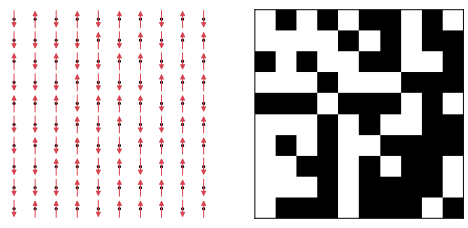

In [3]:
L = 10
σ = initialize_config(L)

# visualize
fig,ax = plt.subplots(1,2,figsize=(8,4))

L = 10
for i in range(L):
    for j in range(L):
        ax[0].annotate("", xy=(j, i+0.5*σ[i,j]), xycoords='data',
            xytext=(j, i-0.5*σ[i,j]), textcoords='data',
            arrowprops=dict(arrowstyle="-|>", color=colors[-2]))
        ax[0].scatter(i,j,c='k', s=5)

ax[0].axis('off')
ax[0].axis('equal')

ax[1].matshow(σ, cmap='binary', extent=[0,9,0,9], origin='lower');
ax[1].set_xticks([]);
ax[1].set_yticks([]);

We will consider periodic boundary conditions which is equivalent to wrapping our lattice onto the surface of a torus.

<img src="https://upload.wikimedia.org/wikipedia/commons/6/60/Torus_from_rectangle.gif" width=400px>

In terms of the matrix $\mathbf{\sigma}$, the energy $E$ and magnetizaiton $M$ can be written as:

\begin{align}
E(\mathbf{x}) &= - \frac{1}{2}\sum_{i=0}^{L-1} \sum_{j=0}^{L-1} \sigma[i,j]\left(\sigma[i+1,j] + \sigma[i-1,j] + \sigma[i,j+1] + \sigma[i,j-1]\right) \\
M(\mathbf{x}) &= \frac{1}{N} \sum_{i=0}^{L-1} \sum_{j=0}^{L-1} \sigma[i,j]\, .
\end{align}

## Markov Chain Monte Carlo

If you want to learn more about Markov Chain Metropolis Monte Carlo methods see [2D_Ising_Model_Monte_Carlo.ipynb](./2D_Ising_Model_Monte_Carlo.ipynb) or my [short course](https://github.com/agdelma/IntroMonteCarlo). 

Ultimately the goal is to sample spin configurations $\sigma$ from the Boltzmann probability:

\begin{equation}
\pi(\sigma) = \frac{\mathrm{e}^{-\beta E(\sigma)}}{\mathcal{Z}}
\end{equation}

which can be done via Metropolis Monte Carlo.

### Algorithm

Fix the temperature $T$.

**Repeat**
1. Select a random spin to flip
2. Calculate $\Delta E = 2\sigma[k,\ell]\left(\sigma[k+1,\ell] + \sigma[k-1,\ell] + \sigma[k,\ell+1] + \sigma[k,\ell-1]\right)$
3. Generate a uniform random number $r \in \mathcal{U}_{[0,1)}$
4. Perform the Metropolis test
    - If $r < \mathrm{e}^{-\Delta E/T}$: accept the move
    - Otherwise: do nothing
5. Measure the magnetization: $M + \Delta M$ where $\Delta M = 2 \sigma[k,\ell]$.

A Monte Carlo **step** consists of $N=L^2$ updates.

### Loading Simulation Results

For $L=30$ I have performed a classical Monte Carlo simulations and stored a series of configurations and observables to disk.

In [4]:
x = np.loadtxt('../data/Ising2D_config_L30.dat.gz')
y = np.loadtxt('../data/Ising2D_labels_L30.dat')
Tval = np.loadtxt('../data/Ising2D_temps_L30.dat')
estimators = np.loadtxt('../data/Ising2D_estimators_L32.dat.gz')

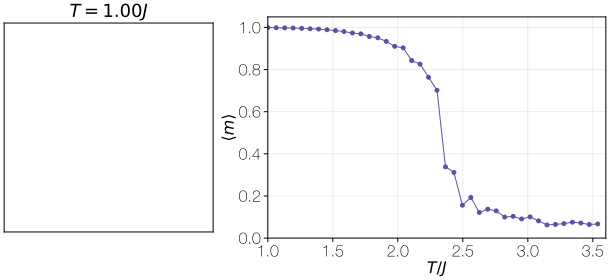

In [5]:
from IPython.display import clear_output, display

L = 30
stride_img = 50
phi = (1 + 5**0.5) / 2

# magnetization per configuration (uses ALL configs)
m_cfg = np.abs(x.mean(axis=1))

fig, (ax_img, ax_m) = plt.subplots(
    1, 2,
    figsize=(4 + 4*phi, 4),
    gridspec_kw={"width_ratios": [1.0, phi]}
)

# --- init config panel ---
cfg0 = x[0].reshape(L, L)
im = ax_img.matshow(cfg0, cmap="binary", vmin=-1, vmax=1)
ax_img.set_xticks([]); ax_img.set_yticks([])
title = ax_img.set_title(f"$T = {Tval[0]:.2f}J$")

# --- init magnetization panel ---
ax_m.set_xlabel("$T / J$")
ax_m.set_ylabel(r"$\langle m \rangle$")
ax_m.grid(True, alpha=0.3)

# fixed limits with LOW T on the left, HIGH T on the right:
ax_m.set_xlim(1.0, 3.6)
ax_m.set_ylim(0.0, 1.05)

(line,) = ax_m.plot([], [], marker="o", markersize=4, linewidth=1)

T_points, M_points = [], []
curr_T = Tval[0]
sum_m = 0.0
count = 0

def flush_bin(T, sum_m, count):
    if count == 0:
        return
    T_points.append(T)
    M_points.append(sum_m / count)

for i in range(len(x)):
    T = Tval[i]

    if not np.isclose(T, curr_T, rtol=0):
        flush_bin(curr_T, sum_m, count)
        curr_T = T
        sum_m = 0.0
        count = 0

    sum_m += m_cfg[i]
    count += 1

    update_now = (i % stride_img == 0) or (count == 1) or (i == len(x) - 1)
    if update_now:
        cfg = x[i].reshape(L, L) if x.ndim == 2 else x[i]
        im.set_data(cfg)
        title.set_text(f"$T = {T:.2f}J$")

        T_plot = np.asarray(T_points + [curr_T])
        M_plot = np.asarray(M_points + [sum_m / count])
        line.set_data(T_plot, M_plot)

        clear_output(wait=True)
        display(fig)
        plt.pause(0.01)

flush_bin(curr_T, sum_m, count)
plt.close(fig)

### Comparing with the **exact** Onsager solution:

\begin{equation}
m = \left[1-\left(\sinh\frac{2J}{k_{\rm B}T}\right)^{-4}\right]^{\frac{1}{8}}
\end{equation}

In [6]:
def magnetization_exact_(T):
    '''We use units where J/k_B = 1.'''
    Tc = 2.0/np.log(1.0+np.sqrt(2.0))
    if T < Tc:
        return (1.0 - np.sinh(2.0/T)**(-4))**(1.0/8)
    else:
        return 0.0
magnetization_exact = np.vectorize(magnetization_exact_)

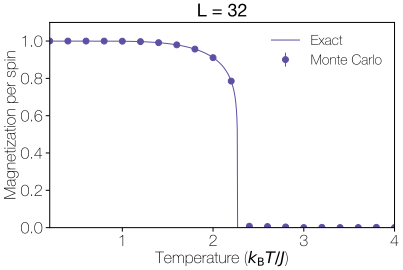

In [7]:
lT = np.linspace(0.01,4,1000)
lL = 32

plt.plot(lT,magnetization_exact(lT),'-', linewidth=1, label='Exact', color=colors[0])
plt.errorbar(estimators[:,0],np.abs(estimators[:,5])/lL**2,yerr=estimators[:,6]/lL**2, linewidth=1, marker='o', 
             markersize=6, elinewidth=1, label='Monte Carlo', linestyle='None', color=colors[0])
plt.xlim(0.2,4)
plt.ylim(0,1.1)
plt.xlabel(r'Temperature ($k_{\rm B}T/J$)')
plt.ylabel('Magnetization per spin')
plt.title("L = 32")

plt.legend();

## Machine Learning Phase Transitions

Let's investigate the raw data stored in the feature matrix $\mathbf{x}$

In [8]:
x

array([[ 1.,  1.,  1., ..., -1., -1., -1.],
       [ 1.,  1., -1., ..., -1.,  1.,  1.],
       [ 1.,  1., -1., ...,  1.,  1.,  1.],
       ...,
       [-1., -1., -1., ..., -1., -1., -1.],
       [-1., -1., -1., ..., -1., -1., -1.],
       [-1., -1., -1., ..., -1., -1., -1.]])

Each row `i` corresponds to a valid configuration of the Ising model at the associated temperature value in `Tval[i]`.  

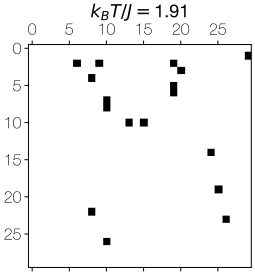

In [9]:
i = 10000
plt.matshow(x[i,:].reshape(L,L), cmap='binary')
plt.title('$k_{B}T/J = $' +f'{Tval[i]:.2f}');

The *label* of each configuration (encoded in $\mathbf{y}$) is a binary such that

\begin{equation}
y[i] = \begin{cases}
1 & \texttt{Tval[i]} > T_c \\
0 & \texttt{Tval[i]} < T_c
\end{cases}
\end{equation}

### Goal: Can we train a deep neural network to *learn* the Ising model phase transition

To test this we need to split our data into a train/test set and we will use a traditional 1-hot encoding for the binary label.

In [10]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)
x_test, x_val, y_test, y_val = train_test_split(x_test, y_test, test_size=0.5, random_state=42)

# use a built-in function to get 1-hot encoding
num_classes = 2
y_train_hot = keras.utils.to_categorical(y_train, num_classes)
y_val_hot = keras.utils.to_categorical(y_val, num_classes)
y_test_hot = keras.utils.to_categorical(y_test, num_classes)

L = int(np.sqrt(x[0].shape[0]))

### Define a deep neural network architecture

In [11]:
model = keras.Sequential([
    keras.Input(shape=(L*L,)),
    layers.Dense(10, activation="relu"),
    layers.Dense(num_classes, activation="softmax"),
])

model.summary()
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │         9,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            22 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,032 (35.28 KB)

 Trainable params: 9,032 (35.28 KB)

 Non-trainable params: 0 (0.00 B)

### This is a schematic of out our deep neural network looks like, with 1 hidden layer.

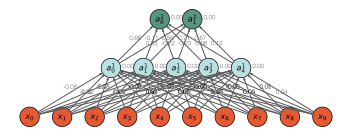

In [12]:
weights = [layer.weights[0].numpy() for layer in model.layers]
biases = [layer.weights[1].numpy() for layer in model.layers]
ml4s.draw_network([10,5,2], weights=weights, biases=biases)

### Train the network

In [13]:
batch_size = 32
epochs = 10

training = model.fit(x_train,y_train_hot, batch_size=batch_size, epochs=epochs,
                     verbose=1, validation_data=(x_val,y_val_hot))

Epoch 1/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 1s 686us/step - accuracy: 0.8194 - loss: 0.4019 - val_accuracy: 0.9679 - val_loss: 0.1003
Epoch 2/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 476us/step - accuracy: 0.9811 - loss: 0.0636 - val_accuracy: 0.9783 - val_loss: 0.0630
Epoch 3/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 469us/step - accuracy: 0.9878 - loss: 0.0394 - val_accuracy: 0.9742 - val_loss: 0.0847
Epoch 4/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 462us/step - accuracy: 0.9936 - loss: 0.0240 - val_accuracy: 0.9821 - val_loss: 0.0469
Epoch 5/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 466us/step - accuracy: 0.9967 - loss: 0.0136 - val_accuracy: 0.9837 - val_loss: 0.0390
Epoch 6/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 463us/step - accuracy: 0.9978 - loss: 0.0083 - val_accuracy: 0.9833 - val_loss: 0.0432
Epoch 7/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 458us/step - accuracy: 0.9986 - loss: 0.0063 - val_accuracy: 0.9862 - val_loss: 0.0365
Epoch 8/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 464us/step - accuracy: 0.9999 - loss: 0.0029 - 

### Investigate how it learned

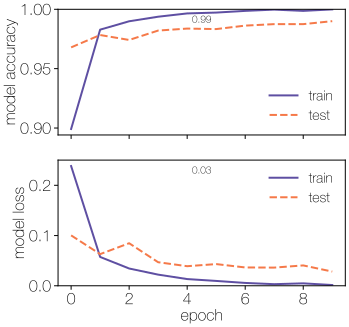

In [14]:
fig,ax = plt.subplots(2,1, sharex=True, figsize=(5,5))

score = model.evaluate(x_val, y_val_hot, verbose=0);

# accuracy
ax[0].plot(training.history['accuracy'], color=colors[0])
ax[0].plot(training.history['val_accuracy'], ls='--', color=colors[-3])
ax[0].set_ylabel('model accuracy')
ax[0].legend(['train', 'test'], loc='best')
ax[0].text(0.5,0.95,f'{score[1]:.2f}',horizontalalignment='center',verticalalignment='top', 
                         transform=ax[0].transAxes)
ax[0].set_ylim(top=1)

# loss
ax[1].plot(training.history['loss'], color=colors[0])
ax[1].plot(training.history['val_loss'], ls='--', color=colors[-3])
ax[1].set_ylabel('model loss')
ax[1].set_xlabel('epoch')
ax[1].set_ylim(bottom=0)
ax[1].text(0.5,0.95,f'{score[0]:.2f}',horizontalalignment='center',verticalalignment='top', 
                         transform=ax[1].transAxes)
ax[1].legend(['train', 'test'], loc='best');

### Evaluate the Model

In [15]:
predictions_prob_train = model(x_train)
predictions_prob_test = model(x_test)

predictions_train = np.argmax(predictions_prob_train,axis=1)
predictions_test = np.argmax(predictions_prob_test,axis=1)

mistakes_train = np.where(predictions_train != y_train)[0]
mistakes_test = np.where(predictions_test != y_test)[0]

num_mistakes_train,num_mistakes_test = len(mistakes_train),len(mistakes_test)

print(f'Train Mistakes: {100*num_mistakes_train/x_train.shape[0]:.2f}%')
print(f'Test Mistakes : {100*num_mistakes_test/x_test.shape[0]:.2f}%')

Train Mistakes: 0.00%
Test Mistakes : 0.75%


In [16]:
predictions_prob_x = model(x)
predictions_x = np.argmax(predictions_prob_x,axis=1)

In [17]:
T,T_idx,T_counts = np.unique(Tval,return_index=True, return_counts=True)
T_idx = T_idx[::-1]
T_counts = T_counts[::-1]

ave_accuracy = np.ones_like(T)
ave_output = np.zeros([T.shape[0],2])

for i in range(0,T_idx.shape[0]-1):
    idx = np.s_[T_idx[i]:T_idx[i+1]]
    ave_accuracy[i] = np.sum(predictions_x[idx] == y[idx])/T_counts[i]
    
    ave_output[i,0] = np.average(predictions_prob_x[idx,0])
    ave_output[i,1] = np.average(predictions_prob_x[idx,1])

    
idx = np.s_[T_idx[-1]:x.shape[0]-1]
ave_accuracy[-1] = np.sum(predictions_x[idx] == y[idx])/T_counts[i]
ave_output[-1,0] = np.average(predictions_prob_x[idx,0])
ave_output[-1,1] = np.average(predictions_prob_x[idx,1])

### Plot the Prediction from the DNN

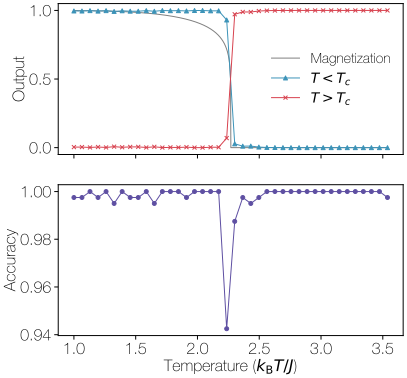

In [18]:
fig,ax = plt.subplots(2,1, sharex=True, figsize=(6,6))

lT = np.linspace(T[0],T[-1],1000)
ax[0].plot(lT,magnetization_exact(lT),'-', linewidth=1, label='Magnetization', color='gray')

ax[0].plot(T,ave_output[:,1], marker='^', label=r'$T < T_c$', color=colors[1],markersize=4, linewidth=1)
ax[0].plot(T,ave_output[:,0], marker='x', label=r'$T > T_c$', color=colors[-2],markersize=4, linewidth=1)
ax[0].set_ylabel('Output')
ax[0].legend()


ax[1].plot(T,ave_accuracy, marker='o', color=colors[0],markersize=4, linewidth=1)
ax[1].set_ylabel('Accuracy')

ax[1].set_xlabel(r'Temperature ($k_{\rm B}T/J$)');